In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.python.keras.regularizers import l1_l2

2025-07-31 16:47:07.089605: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 16:47:07.138350: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 16:47:07.162018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753962427.211776   38766 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753962427.224213   38766 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753962427.342297   38766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
data=pd.read_csv('/home/hammadali08/Vidoes/CSV file/Diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
x1=data.iloc[:,:-1]
y1=data['Outcome']

In [4]:
from imblearn.over_sampling import RandomOverSampler
ru=RandomOverSampler()

In [5]:
x,y=ru.fit_resample(x1,y1)
x.shape

(1000, 8)

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
ss=StandardScaler()
ss.fit(x)

StandardScaler()

In [8]:
x=pd.DataFrame(ss.transform(x),columns=x.columns)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.521513,0.700835,0.119286,0.866176,-0.678621,0.105507,0.394271,1.326562
1,-0.884182,-1.246444,-0.180930,0.502999,-0.678621,-0.776978,-0.406909,-0.283446
2,1.083790,1.782657,-0.281001,-1.252354,-0.678621,-1.193008,0.524898,-0.198709
3,-0.884182,-1.122807,-0.180930,0.139823,0.066646,-0.587874,-0.941029,-1.130819
4,-1.165320,0.360834,-1.481863,0.866176,0.653345,1.303167,5.215864,-0.113972
...,...,...,...,...,...,...,...,...
995,-0.321904,0.082651,0.119286,0.260882,0.827770,-0.045776,0.167850,-0.622395
996,1.083790,-0.628260,1.520290,0.926705,-0.678621,1.328381,-0.732026,0.902875
997,1.646068,-0.010076,0.019214,0.321411,0.233142,-0.209666,-0.830722,0.563926
998,-0.884182,0.082651,-1.081576,1.471470,0.859483,0.975386,0.353631,-0.876607


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
import tensorflow

In [12]:
from keras.models import Sequential
from keras.callbacks import EarlyStopping    # for avoiding Overfiting
from keras.regularizers import l1_l2           # Regularization to avoid Overfittig
from keras.layers import Dense
from keras.losses import mean_absolute_error

In [13]:
sq=Sequential()

In [14]:
sq.add((Dense(8,activation='relu',kernel_regularizer=l1_l2()))) # Kernel Regularizer to avoid Overfitting
sq.add(Dense(6,activation='relu'))
sq.add(Dense(3,activation='relu'))
sq.add(Dense(1,activation='sigmoid'))

In [15]:
sq.compile(optimizer='adam',loss='mean_absolute_error',metrics=['accuracy'])

2025-07-31 16:47:12.658913: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
sq.fit(x_train,y_train,epochs=40,batch_size=10,validation_data=(x_test,y_test),callbacks=EarlyStopping())
# Validation data is for getting accuracy and loss of Test data
# Call back is used for avoiding Overfitting

Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4988 - loss: 0.4968 - val_accuracy: 0.5100 - val_loss: 0.4910
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5500 - loss: 0.4879 - val_accuracy: 0.5750 - val_loss: 0.4818
Epoch 3/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6237 - loss: 0.4739 - val_accuracy: 0.5900 - val_loss: 0.4652
Epoch 4/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6700 - loss: 0.4477 - val_accuracy: 0.6850 - val_loss: 0.4249
Epoch 5/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6988 - loss: 0.3999 - val_accuracy: 0.7050 - val_loss: 0.3683
Epoch 6/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7225 - loss: 0.3450 - val_accuracy: 0.7500 - val_loss: 0.3194
Epoch 7/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: 0.3050 - val_accuracy: 0.7350 - val_loss: 0.2914
Epoch 8/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7425 - loss: 0.2820 - val_accuracy: 0.7300 - val_loss:

In [17]:
from sklearn.metrics import confusion_matrix

In [18]:
confusion_matrix(y_train,sq.predict(x_train).round())

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[292, 109],
       [ 66, 333]])

In [19]:
prd_y=sq.predict(x_train)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [20]:
prd_y_data=[]
for i in prd_y:
    if i>=0.5:
        prd_y_data.append(1)
    else:
        prd_y_data.append(0)

In [21]:
prd=sq.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [22]:
prd_data=[]
for i in prd:
    if i>=0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)


In [23]:
from sklearn.metrics import accuracy_score

In [24]:
accuracy_score(y_test,prd_data)

0.745

In [25]:
accuracy_score(y_train,prd_y_data)

0.78125

In [26]:
sq.history.history     # Validation data was used up there to get the val_accuracy(test data accuracy)

{'accuracy': [0.4987500011920929,
  0.550000011920929,
  0.6237499713897705,
  0.6700000166893005,
  0.6987500190734863,
  0.7225000262260437,
  0.7337499856948853,
  0.7425000071525574,
  0.7450000047683716,
  0.7524999976158142,
  0.7587500214576721,
  0.7562500238418579,
  0.7587500214576721,
  0.7637500166893005,
  0.7599999904632568,
  0.7674999833106995,
  0.7749999761581421,
  0.7762500047683716],
 'loss': [0.4968092739582062,
  0.48788607120513916,
  0.4738525152206421,
  0.4476642906665802,
  0.399897038936615,
  0.3450049161911011,
  0.3049936592578888,
  0.28199273347854614,
  0.26824912428855896,
  0.25962886214256287,
  0.2526765465736389,
  0.24844644963741302,
  0.24479028582572937,
  0.24201545119285583,
  0.24003873765468597,
  0.2378716617822647,
  0.23592430353164673,
  0.23497037589550018],
 'val_accuracy': [0.5099999904632568,
  0.574999988079071,
  0.5899999737739563,
  0.6850000023841858,
  0.7049999833106995,
  0.75,
  0.7350000143051147,
  0.7300000190734863,
 

In [27]:
train_accuracy=sq.history.history['accuracy']
test_accuracy=sq.history.history['val_accuracy']

This basically shows the Overfitting

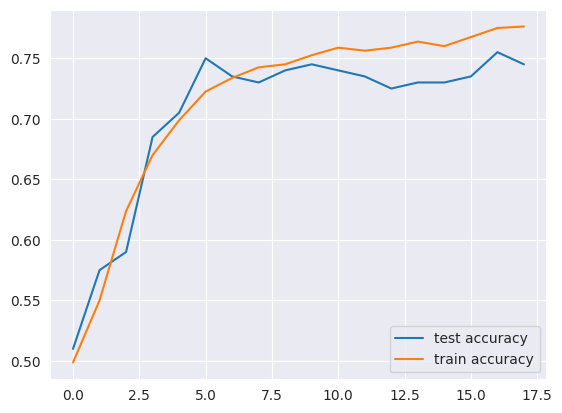

In [28]:
plt.plot(test_accuracy,label='test accuracy')
plt.plot(train_accuracy,label='train accuracy')
plt.legend()
plt.show()